In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams.update({
    'font.size': 14,          
    'axes.titlesize': 20,    
    'axes.labelsize': 20,    
    'xtick.labelsize': 18,    
    'ytick.labelsize': 18,   
    'legend.fontsize': 18,   
    'figure.dpi': 150         
})

# Synchronization, devil's staircase, and fractional Shapiro steps

The synchronization phenomenon occurs in many aspects of the nature, ranging from classic mechanical systems to quantum domains. The basic idea is that, when the interaction between a "clock" and its drive is strong, the clock would lock onto an that drive. The simplest model that shows synchronization is given by the Adler equation:
$$
\frac{d \varphi}{d t}=\Delta \omega+\varepsilon \sin \varphi,
$$
where $\omega$ and $\varphi$ are the frequency difference and phase difference between to oscillators. This is also the two-oscillator version of the Kuramoto model. Here, $\epsilon$ describes the effective coupling strength between to oscillators. As $\Delta \omega < \epsilon$, the system would synchronize, i.e., $\lim_{t\rightarrow \infty}\dot\phi = 0$ at long-time limit for any given initial conditions.

The Josephoson junction as an nonlinear circuit element is also described by the same equation (RSJ equation, or overdamped RSCJ model), with
$$
\frac{d\phi}{dt}  + I_c \sin\phi = I_{dc}
$$
where $I_c$ is the critical current from the supercurrent term. If the current bias $I_{dc}$ surpass the critical current, the phase difference between two superconductors $\phi$ can no longer synchronize, leading to a non-zero voltage 
$$
V= \overline{\dot\phi}.
$$
Here, the overline means a time average. In the non-synchronized regime, since the phase $\phi$ would just increase, the supercurrent $I_c\sin\phi$ oscillates over time and we call it AC Josephson effect. Therefore, the transition from synchronization to oscillation is the DC-AC transition.

## DC-AC transition of Josephson junction from RSJ model

Here I normalize the current bias and time as $i_{dc} = I_{dc}/I_c$ and $\tau = I_c t$. The equation reads
$$
\frac{d\phi}{d\tau} +  \sin\phi = i_{dc}
$$

In [37]:
def rsj_deriv(phi, t, I_dc):
    return I_dc  - np.sin(phi) 

In [38]:
# --- Parameters ---
I_dc_range = np.linspace(0, 5, 500) # DC current sweep, from 0 to 5I_c
t_max = 500       # Total simulation time
t_steady = 200    # Time to wait for transients to decay before averaging

# --- Simulation ---
V_avg = []
t = np.linspace(0, t_max, 5000)

# Solve the ODE for a given I_dc
for I_dc in I_dc_range:
    
    # Initial phase phi(0) = random number from [-pi,pi]
    phi_sol = odeint(rsj_deriv, np.random.uniform(-np.pi, np.pi), t, args=(I_dc,) ).flatten()
    
    # Voltage V(t) = d(phi)/dt
    V_t = rsj_deriv(phi_sol, t, I_dc)
    
    # Isolate the steady-state portion to find the time-averaged voltage
    steady_state_mask = t > t_steady
    V_mean = np.mean(V_t[steady_state_mask])
    V_avg.append(V_mean)

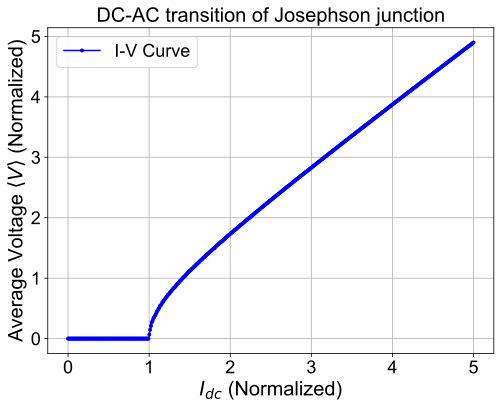

In [39]:
plt.figure(figsize=(8, 6))
plt.plot(I_dc_range, np.array(V_avg), 'b.-', label='I-V Curve')

plt.xlabel('$I_{dc}$ (Normalized)')
plt.ylabel('Average Voltage $\langle V \\rangle$ (Normalized)')
plt.title('DC-AC transition of Josephson junction')
plt.legend()
plt.grid(True)
plt.show()

## Shapiro steps

If we further, add an AC current bias to the Josephoson junction, the I-V characteristic would show Shapiro steps. Those steps occur at $V/\Omega = n$, and the centers locate around $I_{dc}/\Omega =n$.

In [74]:
def rsj_deriv(phi, t, I_dc, I_ac, omega):
    return I_dc + I_ac * np.sin(omega * t) - np.sin(phi) 

In [78]:
# --- Parameters ---
omega = 2       # AC drive frequency
I_ac = 4        # AC drive amplitude
I_dc_range = np.linspace(0, 5*omega, 500)  
t_max = 500        
t_steady = 200     
V_avg = []
t = np.linspace(0, t_max, 5000)

for I_dc in I_dc_range:
    phi_sol = odeint(rsj_deriv, 0, t, args=(I_dc, I_ac, omega)).flatten()
    
    V_t = rsj_deriv(phi_sol, t, I_dc, I_ac, omega)
    
    steady_state_mask = t > t_steady
    V_mean = np.mean(V_t[steady_state_mask])
    V_avg.append(V_mean)

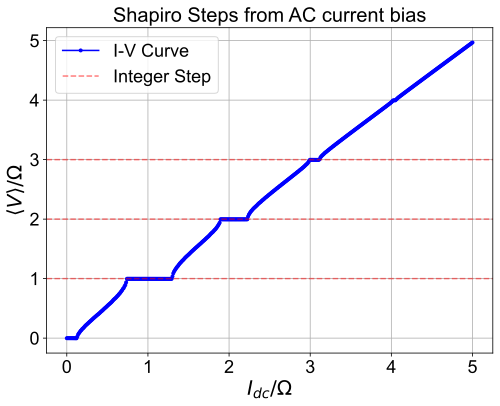

In [82]:
# --- Plotting ---
plt.figure(figsize=(8, 6))
plt.plot(I_dc_range/omega, np.array(V_avg)/omega, 'b.-', label='I-V Curve')


for n in range(1, 4):
    plt.axhline(n , color='r', linestyle='--', alpha=0.5, label='Integer Step' if n==1 else "")


plt.xlabel(r'$I_{dc}/\Omega$')
plt.ylabel(r' $\langle V\rangle/\Omega$ ')
plt.title('Shapiro Steps from AC current bias')
plt.legend()
plt.grid(True)
plt.show()

## Devil's staircase

Except the integer frequencies, the system oscillator can also synchronize to rational frequencies, i.e., $\omega_S/\Omega = p/q$ where $p,q\in \mathbb{Z}$. There are infinite number of rational between two any synchronization steps, and thus the pattern is called devil's staircase. We note that, in Josephson junction, the measurement of the voltage is essentially the frequency of the phase since $\overline{\dot\phi} = \omega_S$. This phenomenon can be decribed by a discrete version of phase evolution, which is called the circle map:
$$
\theta_{n+1}=h(\theta_n, \dot\theta_n)=h\left(\theta_n, g\left(\theta_n\right)\right)=f\left(\theta_n\right).
$$
Consider such a simple sine circle map,
$$
\theta_{n+1}  =f_n\left(\theta_n\right)=\theta_n+\Omega+(K / 2 \pi) \sin \left(2 \pi \theta_n\right)
$$
where the nonlinear coupling constant $K$ sets a transition from mode locking to chaos. The "frequency" of the system is given by the winding number $W$, which is the average phase increase, 
$$
W=\lim _{n \rightarrow \infty}\left(f^n\left(\theta_1\right)-\theta_1\right) / n.
$$
This resembles the voltage $\overline{\dot\phi}$ in Josephson junction. Here we show the Devil's steps, i.e., fractional synchronization frequencies using this model.

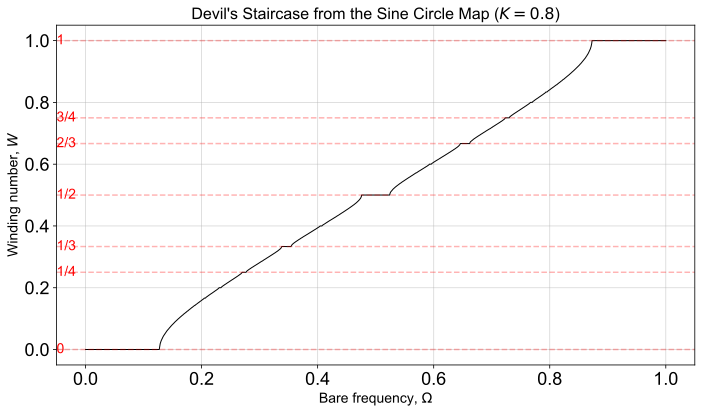

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def compute_winding_number(Omega, K, n_iter=1000, n_transient=200):
    theta = 0.0
    # Transient iterations to let the system settle onto the attractor
    for _ in range(n_transient):
        theta = theta + Omega + (K / (2 * np.pi)) * np.sin(2 * np.pi * theta)
        
    theta_start = theta
    # Actual iterations to compute the winding number
    for _ in range(n_iter):
        theta = theta + Omega + (K / (2 * np.pi)) * np.sin(2 * np.pi * theta)
        
    W = (theta - theta_start) / n_iter
    return W

# Generate Omega values from 0 to 1
Omegas = np.linspace(0, 1, 3000)
K = 0.8 # K=1 is the critical value for a complete devil's staircase

# Calculate winding numbers
W_vals = [compute_winding_number(O, K) for O in Omegas]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(Omegas, W_vals, 'k-', markersize=0.5, linewidth=1)
plt.xlabel(r'Bare frequency, $\Omega$', fontsize=14)
plt.ylabel(r'Winding number, $W$', fontsize=14)
plt.title(rf"Devil's Staircase from the Sine Circle Map ($K={K}$)", fontsize=16)

# Highlight main rational platforms
platforms = [(0, '0'), (1/2, '1/2'), (1/3, '1/3'), (2/3, '2/3'), (1/4, '1/4'), (3/4, '3/4'), (1, '1')]
for val, label in platforms:
    plt.axhline(val, color='red', linestyle='--', alpha=0.3)
    plt.text(-0.05, val, label, color='red', va='center')

plt.grid(True, alpha=0.5)
plt.tight_layout()

It is important to notice that, in this discrete version of phase evolution, the stroboscopic time $\Delta t = 1$ sets the basic frequency, and the winding number show rational steps with respect to the basic frequency. In a continuous version, the RSJ model cannot demonstrate this devil's staircase because there is only one driving frequency. To obtain rational steps, one needs to include a periodic but non-sinusodial supercurrent term. Approximately, we can expand it in terms of $\phi$ using Fourier series and keep to the second order:
$$
\frac{d\phi}{dt} + I_{c1} \sin\phi + I_{c2} \sin 2\phi = I_{dc} + I_{ac} \sin\Omega t 
$$

In [85]:
def rsj_deriv(phi, t, I_dc, I_ac, omega, q):
    """Modified RSJ differential equation with a sin(2*phi) term."""
    # d(phi)/dt = I_dc + I_ac*sin(omega*t) - sin(phi) - q*sin(2*phi)
    return I_dc + I_ac * np.sin(omega * t) - np.sin(phi) - q * np.sin(2 * phi)

In [97]:
# --- Parameters ---
omega = 2        
I_ac = 6        
q = 0.4           # Second harmonic component (causes fractional steps)
I_dc_range = np.linspace(0, 3*omega, 300) # DC current sweep
t_max = 500        
t_steady = 200     


# --- Simulation ---
V_avg = []
t = np.linspace(0, t_max, 5000)

for I_dc in I_dc_range:

    phi_sol = odeint(rsj_deriv, 0, t, args=(I_dc, I_ac, omega, q)).flatten()

    V_t = rsj_deriv(phi_sol, t, I_dc, I_ac, omega, q)

    steady_state_mask = t > t_steady
    V_mean = np.mean(V_t[steady_state_mask])
    V_avg.append(V_mean)

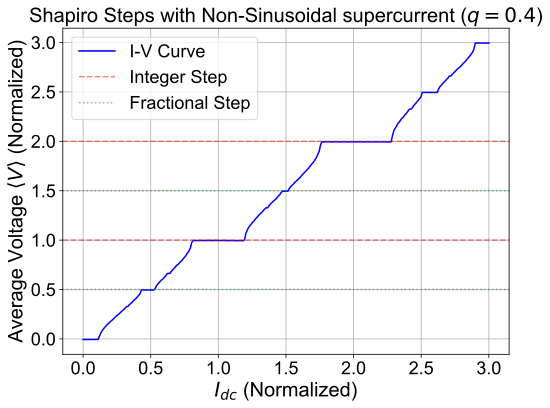

In [98]:
# --- Plotting ---
plt.figure(figsize=(8, 6))
plt.plot(I_dc_range/omega, np.array(V_avg)/omega, 'b-', label='I-V Curve')

# Draw reference lines for integer and half-integer steps
for n in range(1, 3):
    plt.axhline(n , color='r', linestyle='--', alpha=0.5, label='Integer Step' if n==1 else "")
    plt.axhline((n - 0.5) , color='g', linestyle=':', alpha=0.5, label='Fractional Step' if n==1 else "")

plt.xlabel('$I_{dc}$ (Normalized)')
plt.ylabel('Average Voltage $\langle V \\rangle$ (Normalized)')
plt.title('Shapiro Steps with Non-Sinusoidal supercurrent ($q=0.4$)')
plt.legend()
plt.grid(True)
plt.show()

We note that, except introducing this non-sinusodial supercurrent, one can also use a second derivitive to get rational steps. This means we would keep the capacitance term and use RCSJ model instead:
$$
\beta_c \frac{d^2\phi}{dt^2} + \frac{d\phi}{dt} + \sin(\phi) = I_{dc} + I_{ac} \sin(\Omega t) 
$$

Here we assume that the time is unitless, so does other parameters.

In [5]:
def rcsj_second_order(y, t, beta_c, I_dc, I_ac, omega_d):
    """
    RCSJ Model (2nd Order ODE)
    y[0] = theta (phase)
    y[1] = d(theta)/dt (voltage)
    """
    theta, theta_dot = y
    # dy0/dt = y1
    dtheta_dt = theta_dot
    # dy1/dt = (1/beta_c) * (I_dc + A*sin(omega_d*t) - dtheta/dt - sin(theta))
    dtheta_dot_dt = (1.0 / beta_c) * (I_dc + I_ac * np.sin(omega_d * t) - theta_dot - np.sin(theta))
    
    return [dtheta_dt, dtheta_dot_dt]

In [129]:
beta_c = 1.0          # McCumber parameter 
omega = 3     
I_ac = 3            
I_dc_range = np.linspace(0, 1*omega, 2000) 


t_max = 1000         
t_steady = 400       
t = np.linspace(0, t_max, 10000)


V_avg = []

for I_dc in I_dc_range:
    
    # initial condition
    y0 = [0.0, 0.0]
    sol = odeint(rcsj_second_order, y0, t, args=(beta_c, I_dc, I_ac, omega))
    
    V_t = sol[:, 1]
    
    steady_state_mask = t > t_steady
    V_mean = np.mean(V_t[steady_state_mask])
    V_avg.append(V_mean)

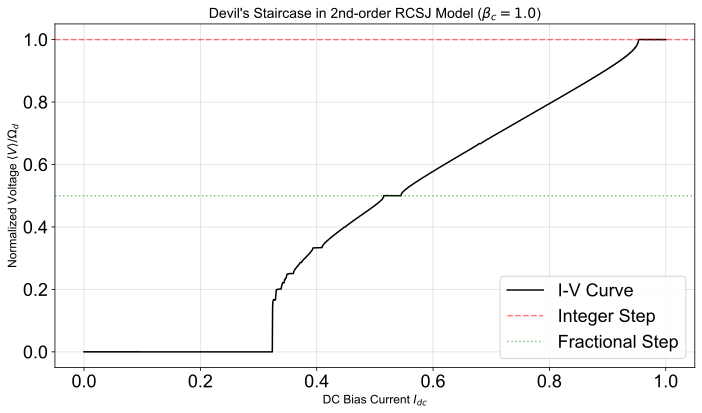

In [131]:
plt.figure(figsize=(10, 6))
plt.plot(I_dc_range/omega, np.array(V_avg)/omega, 'k-', linewidth=1.5, label='I-V Curve')

for n in range(1, 2):
    plt.axhline(n , color='r', linestyle='--', alpha=0.5, label='Integer Step' if n==1 else "")
    plt.axhline((n - 0.5) , color='g', linestyle=':', alpha=0.5, label='Fractional Step' if n==1 else "")
        
plt.xlabel('DC Bias Current $I_{dc}$', fontsize=12)
plt.ylabel('Normalized Voltage $\langle V \\rangle / \Omega_d$', fontsize=12)
plt.title(f"Devil's Staircase in 2nd-order RCSJ Model ($\\beta_c={beta_c}$)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

It is natural to plot the Poincare section of the phase space given by $(\phi, \dot\phi)$. In fact, the total phase space is 3D if we define $\theta = \Omega_d t$ and the Poincare section is $\theta = 0 (2 n\pi)$, i.e., $t = 2n\pi/\Omega_d$. So we just sample points at each drive period to get a cut of the total phase space.

In [3]:
from scipy.integrate import solve_ivp

First, we can plot the evolution of $\phi$ to see if it enters into the limit cyle or chaos. When $I_{dc}$ is within steps, the system synchronize to the drive frequency and there is no chaos.

In [6]:
I_ac=3
omega_d = 2
beta_c = 1
I_dc=0.95*omega_d

t_span = (0, 100*2*np.pi/omega_d) 
t_eval = np.linspace(t_span[0], t_span[1], 1000)
rng = np.random.default_rng(42)
u0 = rng.standard_normal(2)


sol = solve_ivp(
    lambda t, y: rcsj_second_order(y, t, beta_c, I_dc, I_ac, omega_d),
    t_span,
    u0,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-9,
    atol=1e-11
)

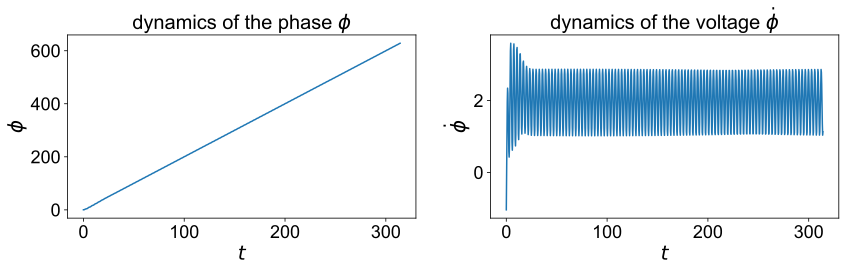

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(sol.t, sol.y[0])
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$\phi$")
axes[0].set_title(r"dynamics of the phase $\phi$")

axes[1].plot(sol.t, sol.y[1])
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel(r"$\dot\phi$")
axes[1].set_title(r"dynamics of the voltage $\dot\phi$")

plt.tight_layout()
plt.show()

What about when $I_{dc}$ is outside of those step regions? Well there seems no answer and what we can do is verify it from numerics. It can either show limit cycle or chaos.

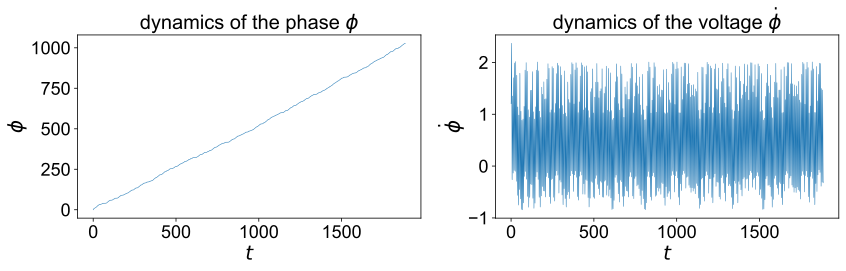

In [17]:
I_ac, omega_d, beta_c = 5.0, 1.0, 5.0
I_dc = 0.6 * omega_d

t_span = (0, 300*2*np.pi/omega_d) 
t_eval = np.linspace(t_span[0], t_span[1], 5000)
rng = np.random.default_rng(20)
u0 = rng.standard_normal(2)


sol = solve_ivp(
    lambda t, y: rcsj_second_order(y, t, beta_c, I_dc, I_ac, omega_d),
    t_span,
    u0,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-9,
    atol=1e-11
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(sol.t, sol.y[0],linewidth = 0.5)
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$\phi$")
axes[0].set_title(r"dynamics of the phase $\phi$")

axes[1].plot(sol.t, sol.y[1],linewidth = 0.5)
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel(r"$\dot\phi$")
axes[1].set_title(r"dynamics of the voltage $\dot\phi$")

plt.tight_layout()
plt.show()

Here I tried different seeds of initial condition, seed = 42 does not work but seed = 20 works.

In [20]:
def differential_equations(t, state, beta_c, I_dc, I_ac, omega_d):
    """
    RCSJ system + tangent vector equation

    state[0] = theta
    state[1] = theta_dot
    state[2:] = deviation (tangent) vector
    """
    theta, theta_dot = state[:2]
    v_dev = state[2:]

    # Original RCSJ dynamics
    dtheta_dt = theta_dot
    dtheta_dot_dt = (I_dc + I_ac * np.sin(omega_d * t) - theta_dot - np.sin(theta)) / beta_c

    # Jacobian matrix of the RCSJ system
    J = np.array([
        [0.0, 1.0],
        [-np.cos(theta) / beta_c, -1.0 / beta_c]
    ])

    # Variational equation
    dv_dev_dt = J @ v_dev

    return np.concatenate(([dtheta_dt, dtheta_dot_dt], dv_dev_dt))

In [21]:
def max_lyapunov_rcsj(
    beta_c,
    I_dc,
    I_ac,
    omega_d,
    u0,
    dt,
    n_steps=20000,
    n_transient=4000,
    seed=42
):

    #Compute the maximum Lyapunov exponent of the driven RCSJ model.

    rng = np.random.default_rng(seed)

    v0 = rng.standard_normal(2)
    v0 = v0 / np.linalg.norm(v0)

    state = np.concatenate((np.asarray(u0, dtype=float), v0))

    log_sum = 0.0
    count = 0
    t = 0.0

    for i in range(n_steps):
        sol = solve_ivp(
            differential_equations,
            (t, t + dt),
            state,
            args=(beta_c, I_dc, I_ac, omega_d),
            method="DOP853",
            rtol=1e-9,
            atol=1e-11
        )

        state = sol.y[:, -1]
        t += dt

        v_dev = state[2:]
        norm_v = np.linalg.norm(v_dev)

        if norm_v == 0:
            raise RuntimeError("Deviation vector became zero.")

        if i >= n_transient:
            log_sum += np.log(norm_v)
            count += 1

        # Renormalize deviation vector
        state[2:] = v_dev / norm_v

    return log_sum / (count * dt)

In [22]:
I_ac, omega_d, beta_c = 5.0, 1.0, 5.0
I_dc = 0.6 * omega_d

rng = np.random.default_rng(20)
u0 = rng.standard_normal(2)

lambda_max = max_lyapunov_rcsj(
    beta_c=beta_c,
    I_dc=I_dc,
    I_ac=I_ac,
    omega_d=omega_d,
    u0=u0,
    dt=0.5/omega_d,
    n_steps=100000,
    n_transient=20000
)

print(lambda_max)

0.11706463988111948


We see that the maximal Lyapunov exponent is larger than 0. To further verify if this is the case, one should inrease the time scale and make sure it converges to a finite number. At those steps, e.g., $I_{dc} \approx 1$ it gets $\lambda_\mathrm{max} \approx 0$.

Further, we can plot the Poincare section to show attractors of the chaos.

In [29]:
def poincare_stroboscopic(beta_c, I_dc, I_ac, omega_d, ini_cond,
                         n_transient=200,n_points=1000,rtol=1e-10,atol=1e-12):
    
    T_drive = 2*np.pi / omega_d
    
    # Sample once per driving period after the transient time
    n_total = n_transient + n_points
    t_eval = T_drive * np.arange(n_total + 1)
    sol = solve_ivp(
        lambda t, y: rcsj_second_order(y, t, beta_c, I_dc, I_ac, omega_d),
        (0, t_eval[-1]),
        ini_cond,
        method="DOP853",
        rtol=rtol,
        atol=atol,
        max_step=T_drive / 50
    )
    
    pts = sol.y[:, n_transient:]

    phi = pts[0]
    phi_dot = pts[1]

    phi_mod = np.mod(phi, 2*np.pi)
    return phi_mod, phi_dot, sol

In [30]:
# generate initial conditions
rng = np.random.default_rng(20)
u0 = rng.standard_normal(2)

I_ac, omega_d, beta_c = 5.0, 1.0, 5.0
I_dc = 0.6 * omega_d

phi_mod, phi_dot, sol = poincare_stroboscopic(beta_c, I_dc, I_ac, omega_d,
    ini_cond = u0,
    n_transient=200,
    n_points=1000)


In [31]:
plt.figure(figsize=(7, 5))
plt.scatter(phi_mod, phi_dot, s=1, alpha=0.35, linewidths=0)

plt.xlabel(r"$\phi \;(\mathrm{mod}\; 2\pi)$")
plt.ylabel(r"$\dot{\phi}$")
plt.title(r"Stroboscopic Poincare Section")
plt.xlim(0, 2*np.pi)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
)
plt.tight_layout()
plt.show()

The trajectories seem to cross each other but actually they do not because this is a cut of the total phase space. Now let's see with this set of parameters how $\dot\phi$ vs $I_{dc}$ looks like:

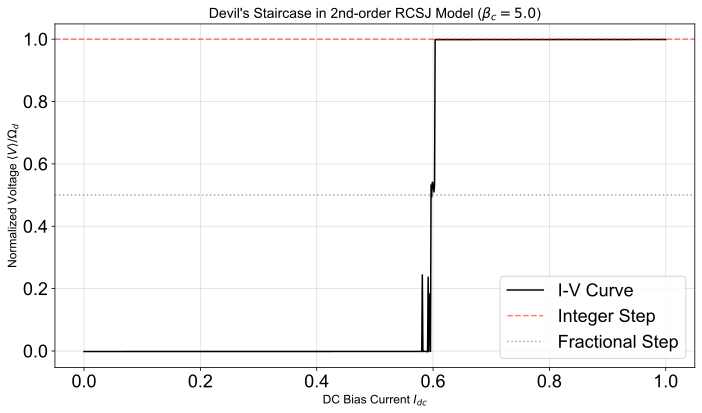

In [32]:
I_ac, omega, beta_c = 5.0, 1.0, 5.0
I_dc_range = np.linspace(0, 1*omega, 1000) 


t_max = 200*2*np.pi / omega_d        
t_steady = t_max /3
t = np.linspace(0, t_max, 10000)


V_avg = []

for I_dc in I_dc_range:
    
    # initial condition
    y0 = [0.0, 0.0]
    sol = odeint(rcsj_second_order, y0, t, args=(beta_c, I_dc, I_ac, omega))
    
    V_t = sol[:, 1]
    
    steady_state_mask = t > t_steady
    V_mean = np.mean(V_t[steady_state_mask])
    V_avg.append(V_mean)
    
    
plt.figure(figsize=(10, 6))
plt.plot(I_dc_range/omega, np.array(V_avg)/omega, 'k-', linewidth=1.5, label='I-V Curve')

for n in range(1, 2):
    plt.axhline(n , color='r', linestyle='--', alpha=0.5, label='Integer Step' if n==1 else "")
    plt.axhline((n - 0.5) , color='g', linestyle=':', alpha=0.5, label='Fractional Step' if n==1 else "")
        
plt.xlabel('DC Bias Current $I_{dc}$', fontsize=12)
plt.ylabel('Normalized Voltage $\langle V \\rangle / \Omega_d$', fontsize=12)
plt.title(f"Devil's Staircase in 2nd-order RCSJ Model ($\\beta_c={beta_c}$)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Remember that, in the previous chaos dynamics, we set $I_{dc} = 0.6$. Now it shows the step transition just happens at $I_{dc}\approx 0.6$. **This indicates that the chaos happens at the edge of those Shapiro steps**.